In [1]:
import numpy as np
import pandas as pd

In [2]:
df=pd.read_csv("socialtrain.csv")

In [3]:
data=pd.read_csv("socialtrain.csv",usecols=["profile pic","description length","#posts","#followers","#follows","fake"])

In [4]:
data

,profile pic,description length,#posts,#followers,#follows,fake
0,1,53,32,1000,955,0
1,1,44,286,2740,533,0
2,1,0,13,159,98,0
3,1,82,679,414,651,0
4,1,0,6,151,126,0
...,...,...,...,...,...,...
571,1,0,33,166,596,1
572,1,21,44,66,75,1
573,1,0,4,96,339,1
574,1,11,0,57,73,1


#datavisualization

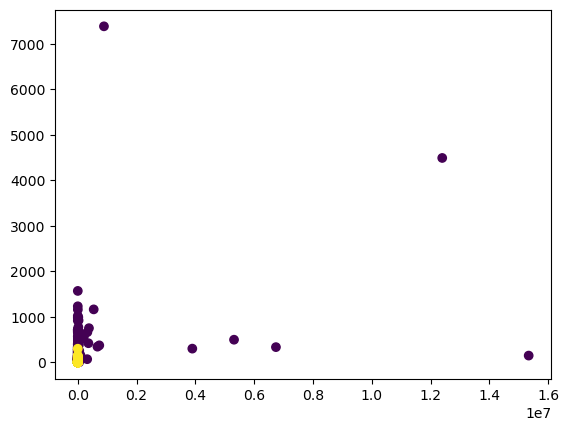

In [5]:
from matplotlib import pyplot as plt
plt.scatter(data["#followers"],data["#posts"],c=data["fake"])

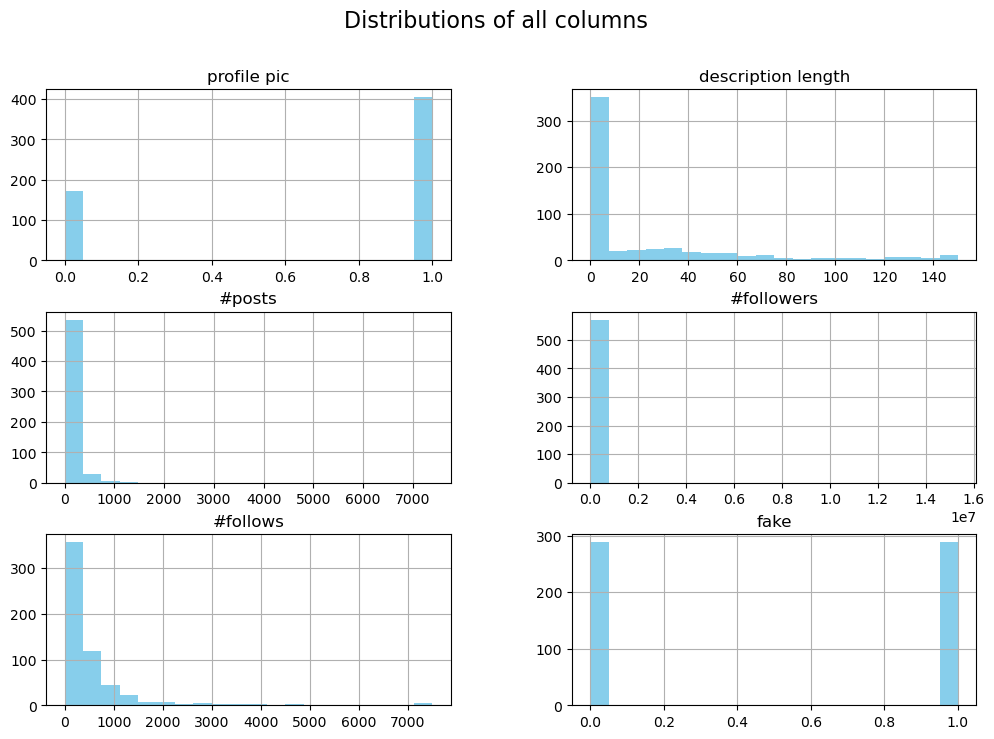

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# All numeric columns
cols = ["profile pic", "description length", "#posts", "#followers", "#follows", "fake"]

data[cols].hist(bins=20, figsize=(12,8), color='skyblue')
plt.suptitle('Distributions of all columns', fontsize=16)
plt.show()

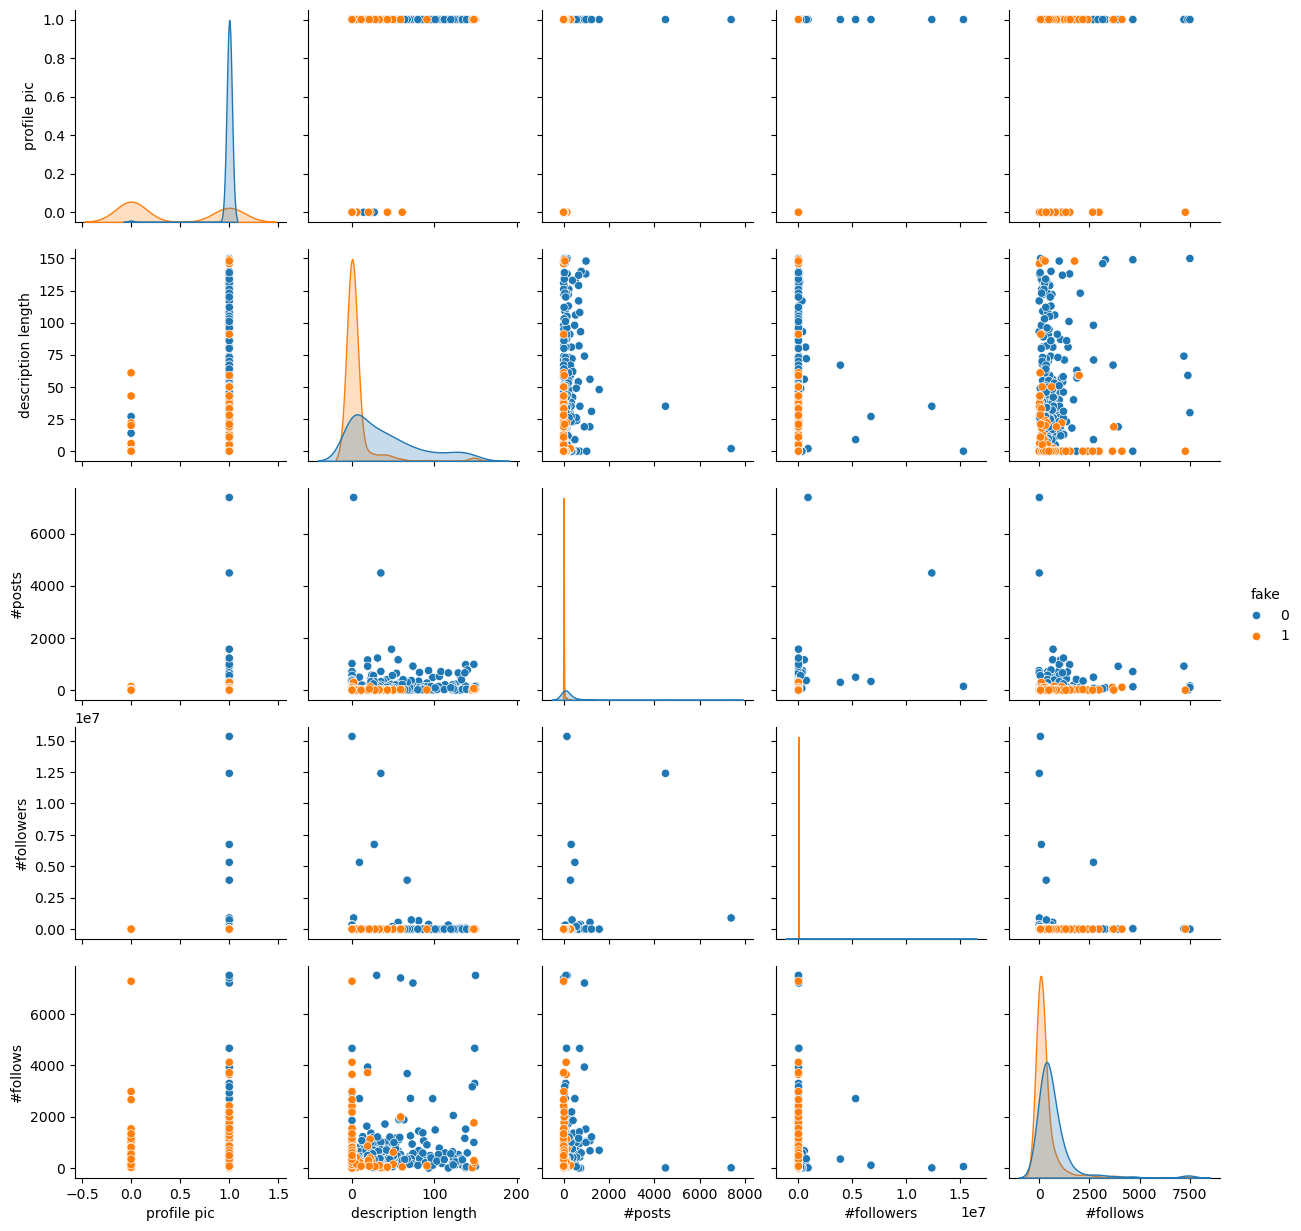

In [7]:
sns.pairplot(data, hue='fake')
plt.show()

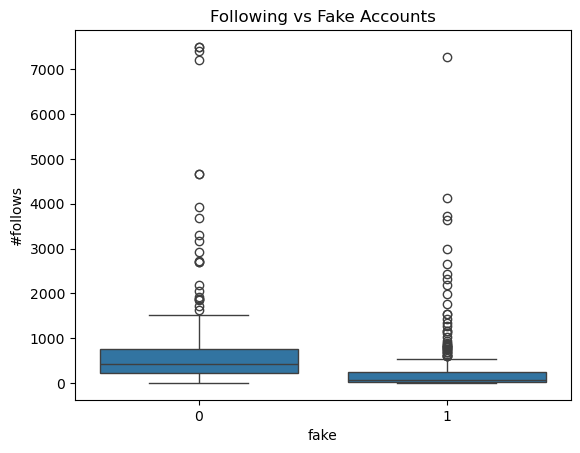

In [8]:
sns.boxplot(x='fake', y='#follows', data=df)
plt.title("Following vs Fake Accounts")
plt.show()

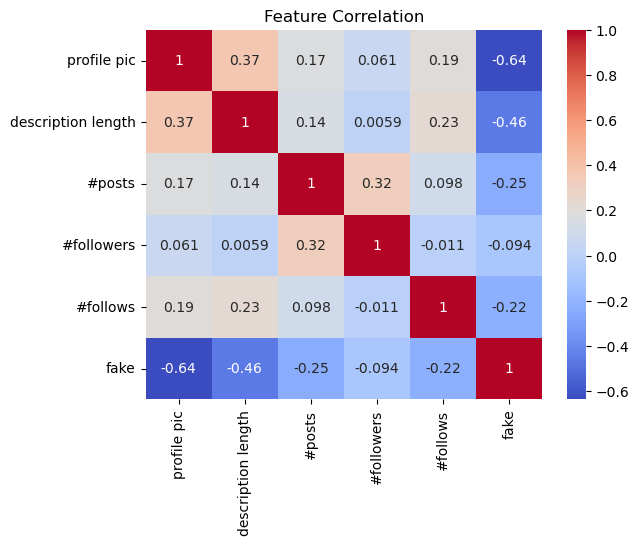

In [9]:
corr = data.corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

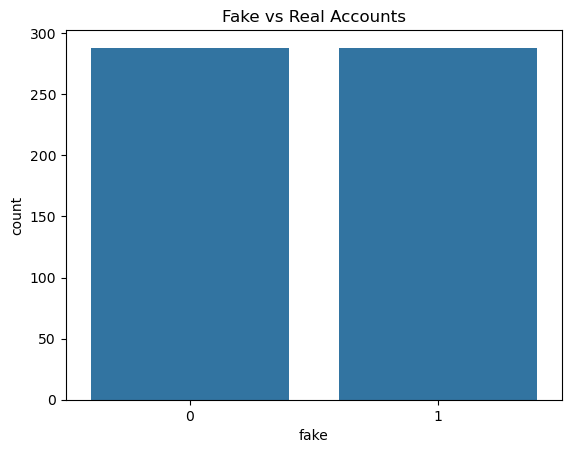

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='fake', data=df)
plt.title("Fake vs Real Accounts")
plt.show()

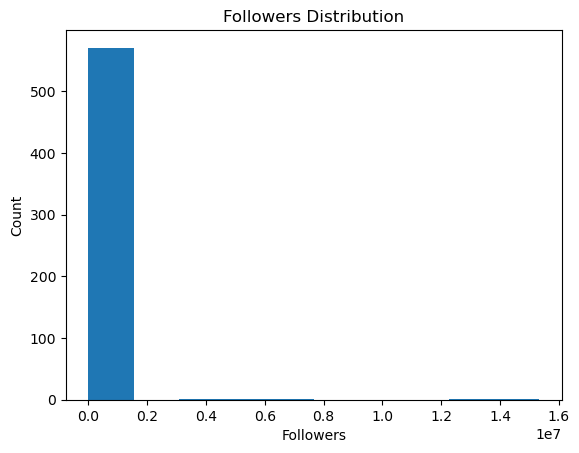

In [11]:
plt.hist(data['#followers'])
plt.title("Followers Distribution")
plt.xlabel("Followers")
plt.ylabel("Count")
plt.show()

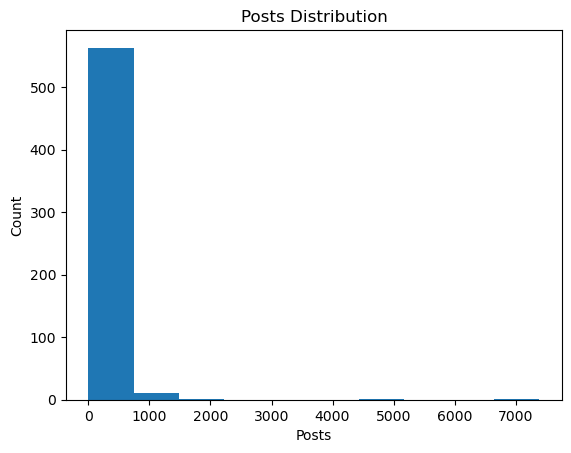

In [12]:
plt.hist(df['#posts'])
plt.title("Posts Distribution")
plt.xlabel("Posts")
plt.ylabel("Count")
plt.show()

In [13]:
data


,profile pic,description length,#posts,#followers,#follows,fake
0,1,53,32,1000,955,0
1,1,44,286,2740,533,0
2,1,0,13,159,98,0
3,1,82,679,414,651,0
4,1,0,6,151,126,0
...,...,...,...,...,...,...
571,1,0,33,166,596,1
572,1,21,44,66,75,1
573,1,0,4,96,339,1
574,1,11,0,57,73,1


In [14]:
X=data.iloc[:,0:5]

In [15]:
X

,profile pic,description length,#posts,#followers,#follows
0,1,53,32,1000,955
1,1,44,286,2740,533
2,1,0,13,159,98
3,1,82,679,414,651
4,1,0,6,151,126
...,...,...,...,...,...
571,1,0,33,166,596
572,1,21,44,66,75
573,1,0,4,96,339
574,1,11,0,57,73


In [16]:
Y=data.iloc[:,-1]

In [17]:
Y

0      0
1      0
2      0
3      0
4      0
      ..
571    1
572    1
573    1
574    1
575    1
Name: fake, Length: 576, dtype: int64

In [18]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test= train_test_split(X,Y,test_size=0.1)

In [19]:
X_train

,profile pic,description length,#posts,#followers,#follows
427,1,0,10,108,304
35,1,9,497,5315651,2703
51,1,57,271,2118,1109
395,0,0,0,11,157
90,1,0,698,1926,1410
...,...,...,...,...,...
56,1,54,75,1759,643
478,0,0,8,39,17
87,1,34,157,1267,899
511,0,0,0,178,828


In [20]:
X_test

,profile pic,description length,#posts,#followers,#follows
320,0,0,0,26,46
231,1,42,111,541,701
385,0,0,0,5,56
113,1,30,33,205,164
498,0,0,0,86,0
10,1,54,648,9884,1173
535,1,19,4,1489,3715
223,1,0,8,319,335
50,1,91,274,1798,461
342,1,9,7,221,244


In [21]:
Y_train

427    1
35     0
51     0
395    1
90     0
      ..
56     0
478    1
87     0
511    1
369    1
Name: fake, Length: 518, dtype: int64

In [22]:
Y_test

320    1
231    0
385    1
113    0
498    1
10     0
535    1
223    0
50     0
342    1
538    1
306    1
147    0
135    0
301    1
4      0
61     0
97     0
325    1
378    1
216    0
116    0
185    0
214    0
465    1
283    0
474    1
155    0
463    1
302    1
558    1
436    1
254    0
284    0
321    1
534    1
412    1
355    1
313    1
124    0
149    0
422    1
328    1
448    1
413    1
556    1
333    1
57     0
526    1
304    1
466    1
9      0
93     0
281    0
300    1
392    1
86     0
541    1
Name: fake, dtype: int64

In [23]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)

In [24]:
X_train

array([[ 0.62946518, -0.6071158 , -0.24130149, -0.09872531, -0.22065416],
       [ 0.62946518, -0.37062066,  0.92628576,  5.44721313,  2.3548921 ],
       [ 0.62946518,  0.89068677,  0.38444856, -0.09662819,  0.64358708],
       ...,
       [ 0.62946518,  0.28631029,  0.11113245, -0.09751607,  0.41813284],
       [-1.58865022, -0.6071158 , -0.26527659, -0.09865227,  0.34190784],
       [ 0.62946518,  0.7067461 , -0.25568655, -0.09881399, -0.38491368]],
      shape=(518, 5))

In [25]:
X_test=scaler.transform(X_test)

In [26]:
X_test

array([[-1.58865022e+00, -6.07115802e-01, -2.65276587e-01,
        -9.88108606e-02, -4.97640797e-01],
       [ 6.29465182e-01,  4.96528198e-01,  8.46996691e-04,
        -9.82735385e-02,  2.05561704e-01],
       [-1.58865022e+00, -6.07115802e-01, -2.65276587e-01,
        -9.88327708e-02, -4.86904881e-01],
       [ 6.29465182e-01,  1.81201341e-01, -1.86158765e-01,
        -9.86241020e-02, -3.70956988e-01],
       [-1.58865022e+00, -6.07115802e-01, -2.65276587e-01,
        -9.87482599e-02, -5.47026011e-01],
       [ 6.29465182e-01,  8.11855055e-01,  1.28830974e+00,
        -8.85255781e-02,  7.12296941e-01],
       [ 6.29465182e-01, -1.07848278e-01, -2.55686548e-01,
        -9.72844487e-02,  3.44136680e+00],
       [ 6.29465182e-01, -6.07115802e-01, -2.46096509e-01,
        -9.85051608e-02, -1.87372824e-01],
       [ 6.29465182e-01,  1.78411286e+00,  3.91641087e-01,
        -9.69620555e-02, -5.21002814e-02],
       [ 6.29465182e-01, -3.70620659e-01, -2.48494018e-01,
        -9.86074085e-02

In [27]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(X_train,Y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [28]:
Y_pred=model.predict(X_test)

In [29]:
Y_pred

array([1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1])

In [30]:
Y_test

320    1
231    0
385    1
113    0
498    1
10     0
535    1
223    0
50     0
342    1
538    1
306    1
147    0
135    0
301    1
4      0
61     0
97     0
325    1
378    1
216    0
116    0
185    0
214    0
465    1
283    0
474    1
155    0
463    1
302    1
558    1
436    1
254    0
284    0
321    1
534    1
412    1
355    1
313    1
124    0
149    0
422    1
328    1
448    1
413    1
556    1
333    1
57     0
526    1
304    1
466    1
9      0
93     0
281    0
300    1
392    1
86     0
541    1
Name: fake, dtype: int64

In [31]:
from sklearn.metrics import accuracy_score
accuracy_score(Y_pred,Y_test)

0.8793103448275862

In [32]:
from sklearn.svm import SVC

model = SVC()
model.fit(X_train, Y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [33]:
from sklearn.metrics import accuracy_score
accuracy_score(Y_pred,Y_test)

0.8793103448275862

In [35]:
from sklearn.metrics import precision_score

precision = precision_score(Y_test, Y_pred)
print(precision)

0.90625


In [36]:
from sklearn.metrics import recall_score

recall = recall_score(Y_test, Y_pred)
print(recall)

0.8787878787878788


In [39]:
import pickle
pickle.dump(model, open("model.pkl", "wb"))

In [42]:
import pickle

model = pickle.load(open("model.pkl", "rb"))

print(model)

SVC()


In [44]:
with open("model.pkl", "rb") as f:
    data = f.read(100)

print(data)

b'\x80\x05\x95y;\x00\x00\x00\x00\x00\x00\x8c\x14sklearn.svm._classes\x94\x8c\x03SVC\x94\x93\x94)\x81\x94}\x94(\x8c\x17decision_function_shape\x94\x8c\x03ovr\x94\x8c\nbreak_ties\x94\x89\x8c\x06kern'
